In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [3]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    transform=transform
)

In [4]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=64,
    shuffle=False
)

In [5]:
class ANN(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784,128)
        self.fc2 = nn.Linear(128,64)
        self.fc3 = nn.Linear(64,10)

    def forward(self,x):

        x = x.view(x.size(0), -1)   # flatten 28x28 → 784

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [6]:
model = ANN().to(device)

In [7]:
Loss = nn.CrossEntropyLoss()

In [8]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
epochs = 21

for epoch in range(epochs):

    for img, labels in train_loader:

        img = img.to(device)
        labels = labels.to(device)

        outputs = model(img)

        loss = Loss(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.2421
Epoch 2, Loss: 0.0466
Epoch 3, Loss: 0.1133
Epoch 4, Loss: 0.0628
Epoch 5, Loss: 0.0625
Epoch 6, Loss: 0.0632
Epoch 7, Loss: 0.0474
Epoch 8, Loss: 0.0462
Epoch 9, Loss: 0.0090
Epoch 10, Loss: 0.0061
Epoch 11, Loss: 0.0023
Epoch 12, Loss: 0.0009
Epoch 13, Loss: 0.0002
Epoch 14, Loss: 0.0044
Epoch 15, Loss: 0.0003
Epoch 16, Loss: 0.0200
Epoch 17, Loss: 0.0002
Epoch 18, Loss: 0.0000
Epoch 19, Loss: 0.0023
Epoch 20, Loss: 0.0070
Epoch 21, Loss: 0.0084
Epoch 22, Loss: 0.0002
Epoch 23, Loss: 0.0025
Epoch 24, Loss: 0.0010
Epoch 25, Loss: 0.0000


In [10]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print("Test Accuracy:", accuracy)

Test Accuracy: 97.71


5 epoch = accuracy 97.75

25 epoch = accuracy 97.71

torch.Size([128, 784])


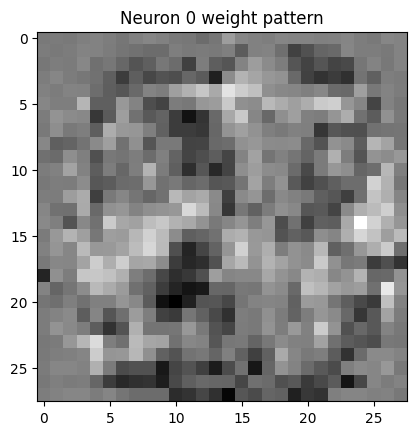

In [13]:
import matplotlib.pyplot as plt

weights = model.fc1.weight.data

print(weights.shape)

w = weights[8].reshape(28,28)

plt.imshow(w, cmap="gray")
plt.title("Neuron 0 weight pattern")
plt.show()


In [17]:
images, labels = next(iter(test_loader))
print(images.shape)
print(labels)

torch.Size([64, 1, 28, 28])
tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9, 0, 6, 9, 0, 1, 5, 9, 7, 3, 4, 9, 6, 6, 5,
        4, 0, 7, 4, 0, 1, 3, 1, 3, 4, 7, 2, 7, 1, 2, 1, 1, 7, 4, 2, 3, 5, 1, 2,
        4, 4, 6, 3, 5, 5, 6, 0, 4, 1, 9, 5, 7, 8, 9, 3])
